In [16]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["JAX_PLATFORMS"] = "cpu"

import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax_cosmo as jc

from fwd_model_tools.field import FieldStatus, ParticleField, DensityField, FlatDensity, SphericalDensity
from fwd_model_tools.normal import gaussian_initial_conditions
from fwd_model_tools.pm import lpt, nbody
from fwd_model_tools.lensing_model import Planck18
# Import lensing API
from fwd_model_tools.lensing import born
from fwd_model_tools.field import SphericalDensity, DensityStatus
from fwd_model_tools.utils import compute_lightcone_shells
from fwd_model_tools.power.theory import compute_theory_cl

## Simulation setup

We configure a moderately sized particle-mesh volume, generate Gaussian initial conditions, and evolve a lightcone that we will later project onto the sphere.

In [ ]:
mesh_size = (256 , 256 , 256)
box_size = (2000.0, 2000.0, 2000.0)
observer_position = (0.5, 0.5, 0.5)
nside = 256
nb_shells = 9
flatsky_npix = (256, 256)

# N-body evolution parameters
t0 = 0.1
t1 = 1.0
dt0 = 0.05
z_source = 0.3

key = jax.random.PRNGKey(42)
cosmo = Planck18()

print(f"Mesh size: {mesh_size}, box size: {box_size} Mpc/h")
print(f"nside={nside}, shells={nb_shells}, source redshift={z_source}")


Mesh size: (256, 256, 256), box size: (2000.0, 2000.0, 2000.0) Mpc/h
nside=256, shells=20, source redshift=0.3


In [3]:
gaussian_field = gaussian_initial_conditions(
    key=key,
    cosmo=cosmo,
    mesh_size=mesh_size,
    box_size=box_size,
    observer_position=observer_position,
    nside=nside,
    flatsky_npix=flatsky_npix,
)

print(gaussian_field)
print(f"Status: {gaussian_field.status}")


DensityField(array=Array(256, 256, 256), mesh_size=(256, 256, 256), box_size=(2000.0, 2000.0, 2000.0), status=initial_field, scale_factors_shape=(1,))
Status: FieldStatus.INITIAL_FIELD


In [4]:
dx_field, p_field = lpt(cosmo, gaussian_field, a=t0, order=1)

max_radius = dx_field.max_comoving_radius
plane_width = dx_field.density_width(nb_shells)

print(f"Displacement field array shape: {dx_field.array.shape}")
print(f"Max comoving radius: {max_radius:.1f} Mpc/h")
print(f"Density plane width: {plane_width:.1f} Mpc/h")

shape of initial force: (256, 256, 256, 3)
growth factor shape: (1,)
Displacement field array shape: (256, 256, 256, 3)
Max comoving radius: 1000.0 Mpc/h
Density plane width: 50.0 Mpc/h


# Weak Lensing on the Sphere

This example walks through generating a spherical lightcone with `fwd_model_tools`, computing convergence via the Born approximation for a single source plane, and comparing the measured angular power spectrum to a theoretical prediction.

In [5]:
r_center, ts = compute_lightcone_shells(
    cosmo=cosmo,
    field=gaussian_field,
    nb_shells=nb_shells,
)

print(f"Shell centers span {float(r_center[-1]):.1f}–{float(r_center[0]):.1f} Mpc/h")
print(f"Shell scale factors span {float(ts[-1]):.3f}–{float(ts[0]):.3f}")

Shell centers span 25.0–975.0 Mpc/h
Shell scale factors span 0.992–0.738


In [6]:
particle_lightcone = nbody(
    cosmo,
    dx_field,
    p_field,
    t1=t1,
    dt0=dt0,
    ts=ts,
    geometry='particles',
)

spherical_lightcone = particle_lightcone.paint_spherical(
    center=r_center,
)

print(spherical_lightcone)
print(f"Lightcone array shape: {spherical_lightcone.array.shape}")


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


SphericalDensity(array=Array(20, 786432), mesh_size=(256, 256, 256), box_size=(2000.0, 2000.0, 2000.0), status=lightcone, scale_factors_shape=(20,))
Lightcone array shape: (20, 786432)


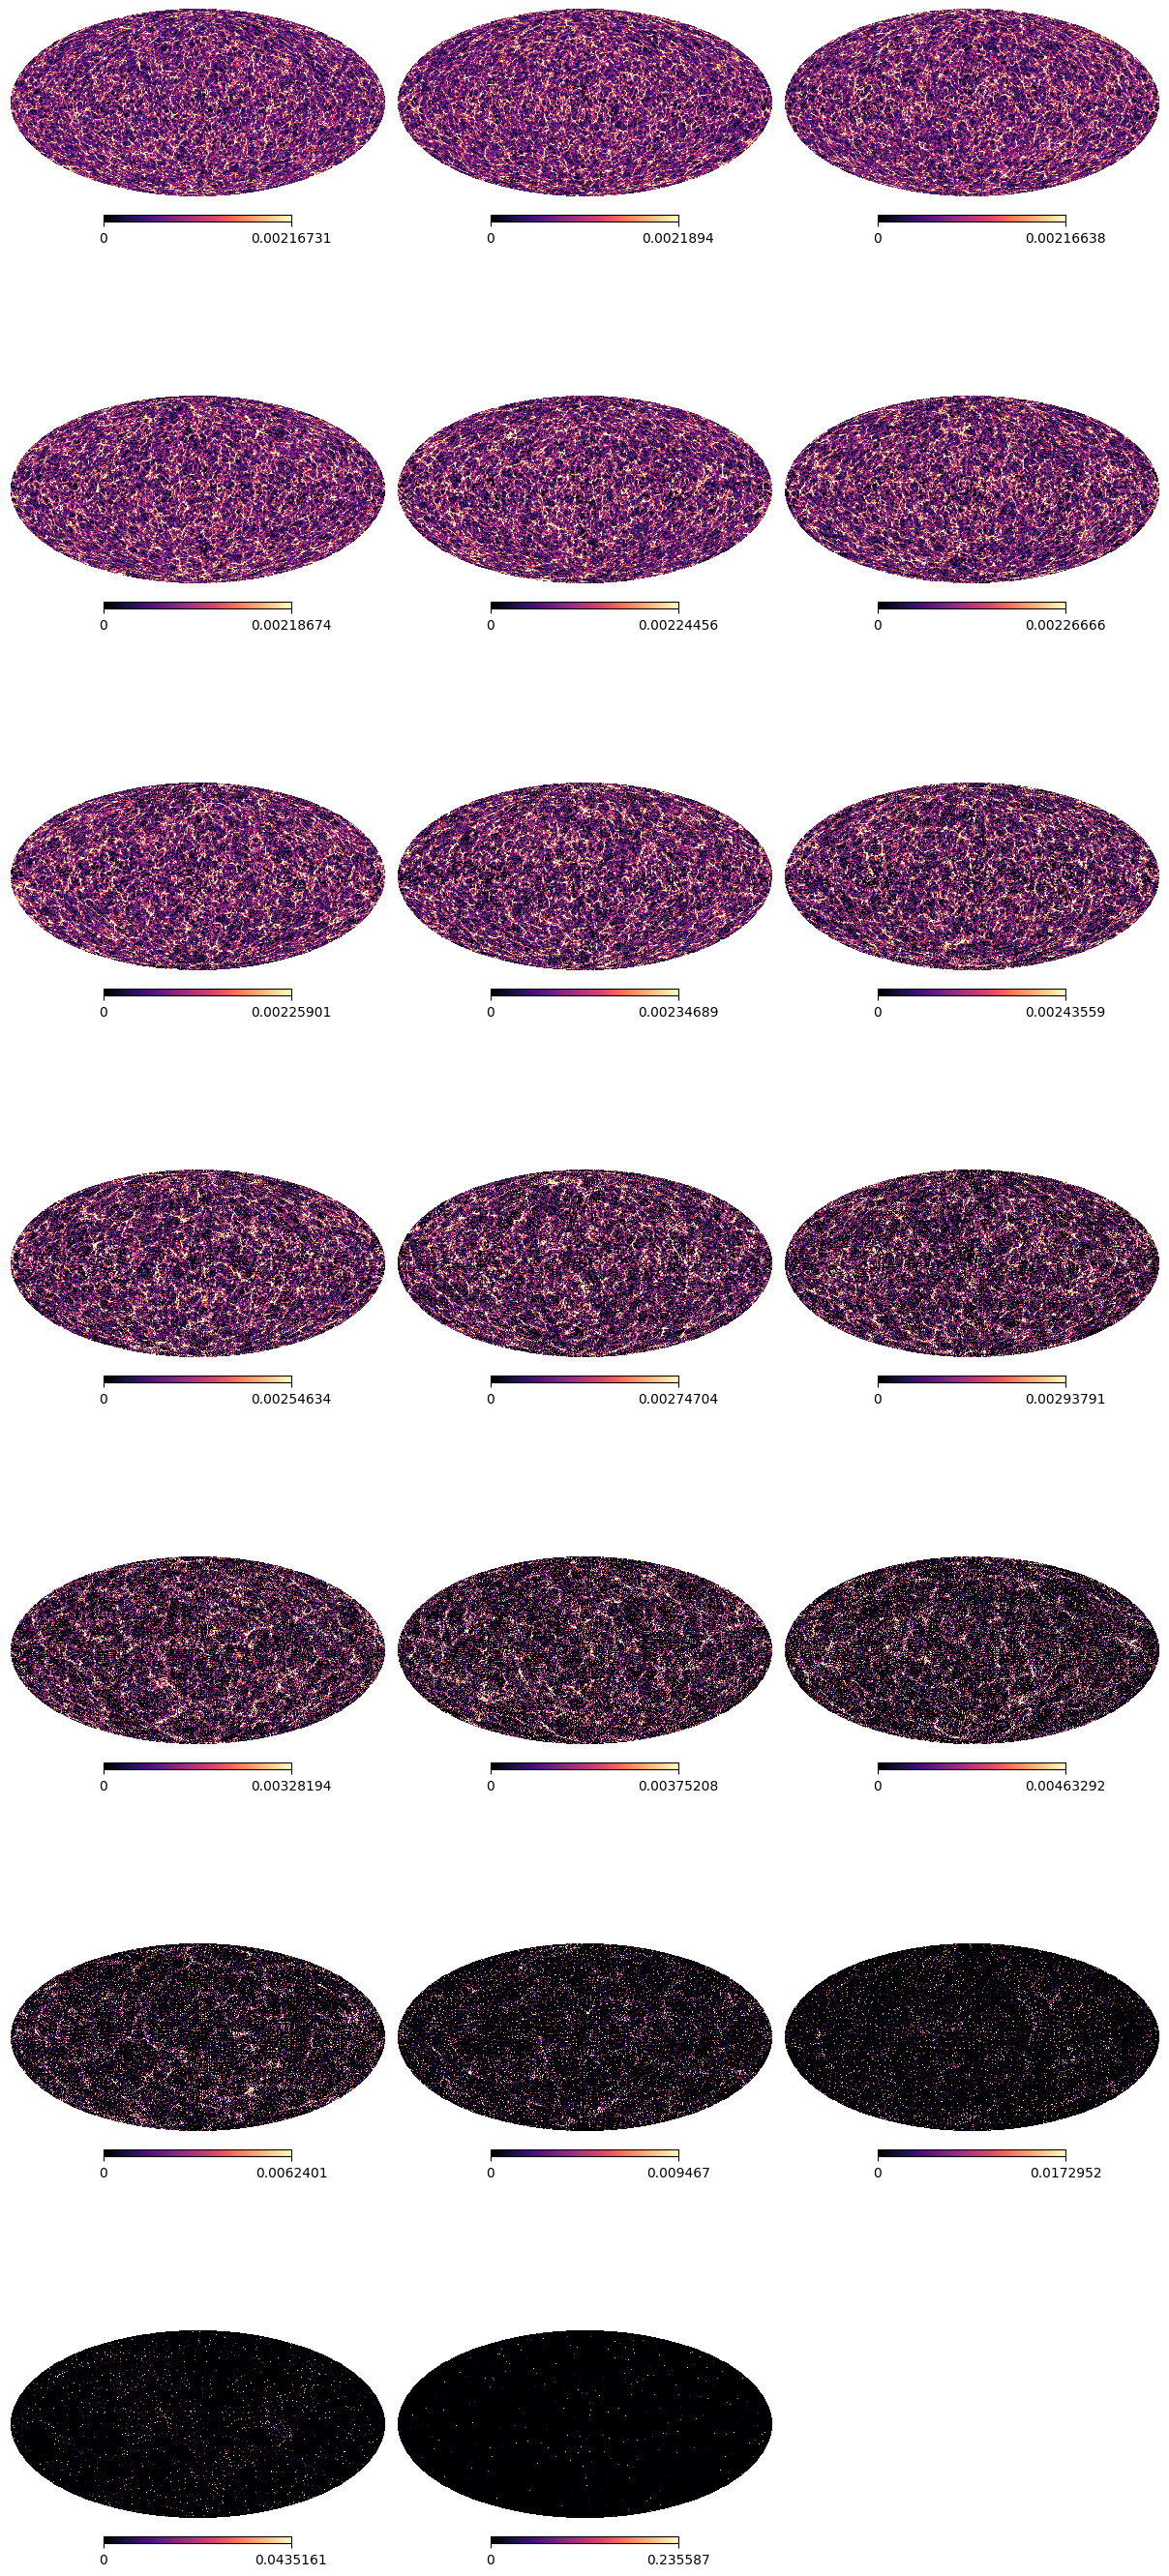

In [7]:
spherical_lightcone.show()

In [12]:
kappa_spherical = born(cosmo, spherical_lightcone, z_source=z_source)

print(kappa_spherical)
print(f"kappa array shape: {kappa_spherical.array.shape}")


SphericalKappaField(array=Array(786432,), mesh_size=(256, 256, 256), box_size=(2000.0, 2000.0, 2000.0), status=kappa, scale_factors_shape=(1,))
kappa array shape: (786432,)


## Convergence map

We visualize the single-source spherical convergence map in Mollweide projection.

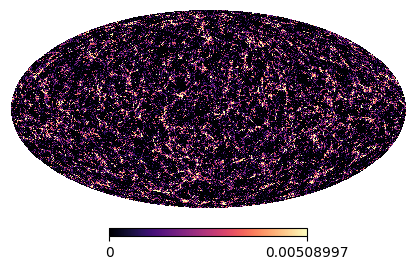

In [13]:
kappa_spherical.show(cmap='magma', ncols=1, apply_log=False)


## Power-spectrum comparison

We measure the angular power spectrum via `SphericalDensity.compute_power_spectrum` and compare it with the theoretical `C_\ell` from `compute_theory_cl`.

In [14]:
power_spectrum = SphericalDensity.compute_power_spectrum(kappa_spherical)
ell_meas = jnp.asarray(power_spectrum.k)
cl_meas = jnp.asarray(power_spectrum.pk)

valid = ell_meas >= 2
ell_meas = ell_meas[valid]
cl_meas = cl_meas[valid]

print(f"Measured ell range: {int(ell_meas[0])}–{int(ell_meas[-1])}")

Measured ell range: 2–767


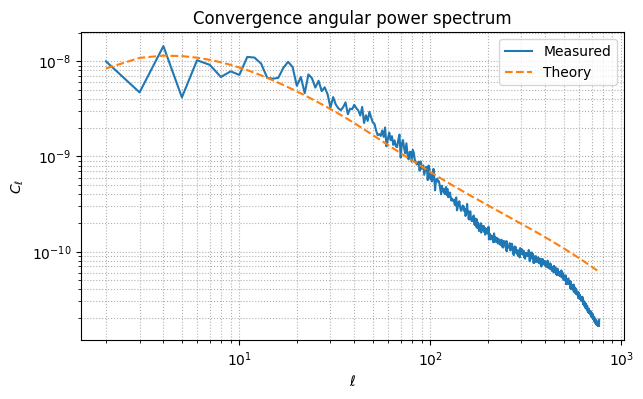

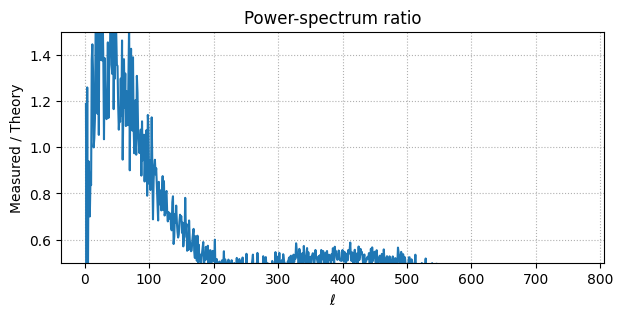

In [17]:
ell_theory = jnp.arange(int(ell_meas[0]), int(ell_meas[-1]) + 1)
cl_theory = compute_theory_cl(cosmo, ell_theory, z_source=z_source)
cl_interp = jnp.interp(ell_theory, ell_meas, cl_meas)

plt.figure(figsize=(7, 4))
plt.loglog(ell_meas, cl_meas, label='Measured')
plt.loglog(ell_theory, cl_theory, label='Theory', linestyle='--')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell$')
plt.title('Convergence angular power spectrum')
plt.legend()
plt.grid(True, which='both', linestyle=':')
plt.show()

plt.figure(figsize=(7, 3))
plt.plot(ell_theory, cl_interp / cl_theory)
plt.xlabel(r'$\ell$')
plt.ylabel('Measured / Theory')
plt.title('Power-spectrum ratio')
plt.grid(True, linestyle=':')
plt.ylim(0.5, 1.5)
plt.show()